In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# display settings
pd.set_option('display.max_columns', None)

In [2]:
orders = pd.read_csv('C://Users//rdama//OneDrive//Desktop//2026 projects//Brazilian E Commerce Public Dataset//raw data//olist_orders_dataset.csv')
customers = pd.read_csv('C://Users//rdama//OneDrive//Desktop//2026 projects//Brazilian E Commerce Public Dataset//raw data//olist_customers_dataset.csv')

# look at the shape
print("Orders :", orders.shape)
print("Customers :",customers.shape)

# look at first few rows
orders.head()

Orders : (99441, 8)
Customers : (99441, 5)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [3]:
# check column names and data types
orders.info()

# check for missing values
orders.isnull().sum()

# see what order statuses exist
orders['order_status'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [4]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

In [5]:
delivered = orders[orders['order_status'] == 'delivered'].copy()
print(delivered.shape)  # should be around 96,000 rows

(96478, 8)


In [6]:
delivered['delivery_delay_days'] = (
    delivered['order_delivered_customer_date'] - 
    delivered['order_estimated_delivery_date']
).dt.days

# positive = late, negative = early, 0 = on time
delivered['is_late'] = delivered['delivery_delay_days'] > 0

# overall on-time rate
on_time_rate = (delivered['is_late'] == False).mean() * 100
print(f"On-time delivery rate: {on_time_rate:.1f}%")

On-time delivery rate: 93.2%


In [7]:
delivered['actual_delivery_days'] = (
    delivered['order_delivered_customer_date'] - 
    delivered['order_purchase_timestamp']
).dt.days

In [8]:
df = delivered.merge(customers, on='customer_id', how='left')

# check it worked
df[['customer_state', 'delivery_delay_days', 'is_late']].head()

,customer_state,delivery_delay_days,is_late
0,SP,-8.0,False
1,BA,-6.0,False
2,GO,-18.0,False
3,RN,-13.0,False
4,SP,-10.0,False


In [9]:
state_performance = df.groupby('customer_state').agg(
    total_orders=('order_id', 'count'),
    late_orders=('is_late', 'sum'),
    avg_delay_days=('delivery_delay_days', 'mean'),
    avg_delivery_days=('actual_delivery_days', 'mean')
).reset_index()

state_performance['late_rate'] = (
    state_performance['late_orders'] / state_performance['total_orders'] * 100
).round(1)

state_performance.sort_values('late_rate', ascending=False).head(10)

,customer_state,total_orders,late_orders,avg_delay_days,avg_delivery_days,late_rate
1,AL,397,85,-8.707809,24.040302,21.4
9,MA,717,125,-9.571827,21.117155,17.4
24,SE,335,51,-10.020896,21.029851,15.2
16,PI,476,66,-11.306723,18.993697,13.9
5,CE,1279,176,-10.804535,20.817826,13.8
4,BA,3256,396,-10.794533,18.866400,12.2
21,RR,41,5,-17.292683,28.975610,12.2
18,RJ,12350,1495,-11.761215,14.848583,12.1
13,PA,946,106,-14.066596,23.316068,11.2
7,ES,1995,214,-10.496241,15.331830,10.7


In [10]:
reviews = pd.read_csv('C://Users//rdama//OneDrive//Desktop//2026 projects//Brazilian E Commerce Public Dataset//raw data//olist_order_reviews_dataset.csv')
df = df.merge(reviews[['order_id', 'review_score']], on='order_id', how='left')

# do late deliveries get worse reviews?
df.groupby('is_late')['review_score'].mean()

is_late
False    4.289999
True     2.271025
Name: review_score, dtype: float64

In [11]:
# load the remaining tables
order_items = pd.read_csv('C://Users//rdama//OneDrive//Desktop//2026 projects//Brazilian E Commerce Public Dataset//raw data//olist_order_items_dataset.csv')
sellers     = pd.read_csv('C://Users//rdama//OneDrive//Desktop//2026 projects//Brazilian E Commerce Public Dataset//raw data//olist_sellers_dataset.csv')

# peek at order_items
print(order_items.shape)
order_items.head()

(112650, 7)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [12]:
# what does order_items look like?
print(order_items.columns.tolist())
print(order_items.shape)
order_items.head()

['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
(112650, 7)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [13]:
# collapse order_items to one row per order
# (some orders have multiple products)
items_agg = order_items.groupby('order_id').agg(
    freight_value = ('freight_value', 'sum'),   # total freight for the order
    price         = ('price', 'sum'),            # total order value
    num_items     = ('order_item_id', 'count'),  # how many items
    seller_id     = ('seller_id', 'first'),      # primary seller
    product_id    = ('product_id', 'first')      # primary product
).reset_index()

print(items_agg.shape)
items_agg.head()

(98666, 6)


,order_id,freight_value,price,num_items,seller_id,product_id
0,00010242fe8c5a6d1ba2dd792cb16214,13.29,58.90,1,48436dade18ac8b2bce089ec2a041202,4244733e06e7ecb4970a6e2683c13e61
1,00018f77f2f0320c557190d7a144bdd3,19.93,239.90,1,dd7ddc04e1b6c2c614352b383efe2d36,e5f2d52b802189ee658865ca93d83a8f
2,000229ec398224ef6ca0657da4fc703e,17.87,199.00,1,5b51032eddd242adc84c38acab88f23d,c777355d18b72b67abbeef9df44fd0fd
3,00024acbcdf0a6daa1e931b038114c75,12.79,12.99,1,9d7a1d34a5052409006425275ba1c2b4,7634da152a4610f1595efa32f14722fc
4,00042b26cf59d7ce69dfabb4e55b4fd9,18.14,199.90,1,df560393f3a51e74553ab94004ba5c87,ac6c3623068f30de03045865e4e10089


In [14]:
# merge items into our main dataframe
df = df.merge(items_agg, on='order_id', how='left')

# now merge sellers to get seller_state and seller_city
df = df.merge(sellers, on='seller_id', how='left')

# check it worked
print(df.shape)
df[['customer_state', 'seller_state', 'freight_value', 'price', 'review_score']].head()

(97007, 24)


,customer_state,seller_state,freight_value,price,review_score
0,SP,SP,8.72,29.99,4.0
1,BA,SP,22.76,118.70,4.0
2,GO,SP,19.22,159.90,5.0
3,RN,MG,27.20,45.00,5.0
4,SP,SP,8.72,19.90,5.0


In [15]:
df['freight_pct_of_price'] = (
    df['freight_value'] / df['price'] * 100
).round(1)

# fix: use round() as a function, not a method
print("Avg freight % of price:", round(df['freight_pct_of_price'].median(), 1))
print("Total columns now:", df.shape[1])

Avg freight % of price: 22.4
Total columns now: 25


In [16]:
# TRIPLE THREAT: orders that are late AND expensive freight AND bad review
# think of it as flagging the "worst of the worst" orders

df['triple_threat'] = (
    (df['is_late'] == True) &                                        # condition 1: late
    (df['review_score'] <= 2) &                                      # condition 2: bad review
    (df['freight_value'] > df['freight_value'].quantile(0.75))       # condition 3: top 25% freight cost
)

# how many triple threat orders exist?
print("Triple threat orders:", df['triple_threat'].sum())
print("That's", round(df['triple_threat'].sum() / len(df) * 100, 1), "% of all orders")

Triple threat orders: 1234
That's 1.3 % of all orders


In [ ]:
import streamlit as st

st.set_page_config(page_title="Olist Delivery Dashboard", layout="wide")

st.title("Last Mile Delivery Analytics")
st.write("Brazilian E-Commerce Dataset · Olist · 2016–2018")

2026-03-04 14:31:53.719 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-04 14:31:53.720 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-04 14:31:54.306 
  command:

    streamlit run c:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-04 14:31:54.307 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-04 14:31:54.309 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-04 14:31:54.313 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [18]:
# export the master dataframe to CSV for Power BI
df.to_csv('olist_master.csv', index=False)

print("Done! File saved as olist_master.csv")
print("Shape:", df.shape)

Done! File saved as olist_master.csv
Shape: (97007, 26)


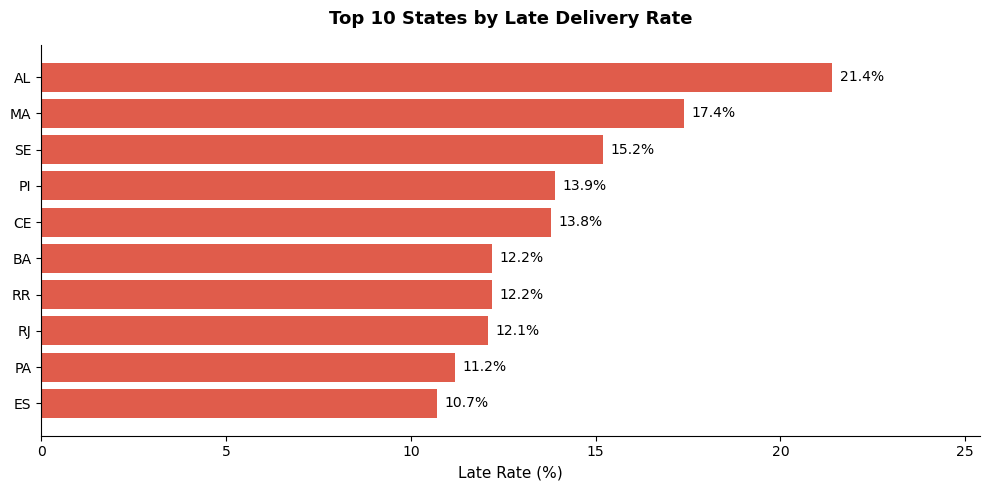

In [19]:
top10_late = state_performance.sort_values('late_rate', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(top10_late['customer_state'], top10_late['late_rate'], color='#e05c4b')

for bar, val in zip(bars, top10_late['late_rate']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)

ax.invert_yaxis()
ax.set_xlabel('Late Rate (%)', fontsize=11)
ax.set_title('Top 10 States by Late Delivery Rate', fontsize=13, fontweight='bold', pad=15)
ax.set_xlim(0, top10_late['late_rate'].max() + 4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

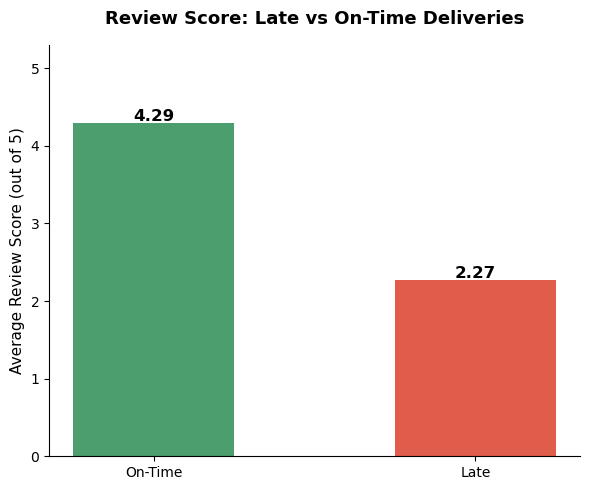

Late orders score 2.02 points lower on average


In [20]:
review_by_late = df.groupby('is_late')['review_score'].mean().reset_index()
review_by_late['label'] = review_by_late['is_late'].map({False: 'On-Time', True: 'Late'})

fig, ax = plt.subplots(figsize=(6, 5))

colors = ['#4c9e6e', '#e05c4b']
bars = ax.bar(review_by_late['label'], review_by_late['review_score'], color=colors, width=0.5)

for bar, val in zip(bars, review_by_late['review_score']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'{val:.2f}', ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('Average Review Score (out of 5)', fontsize=11)
ax.set_title('Review Score: Late vs On-Time Deliveries', fontsize=13, fontweight='bold', pad=15)
ax.set_ylim(0, 5.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

diff = review_by_late[review_by_late['label']=='On-Time']['review_score'].values[0] - \
       review_by_late[review_by_late['label']=='Late']['review_score'].values[0]
print(f'Late orders score {diff:.2f} points lower on average')

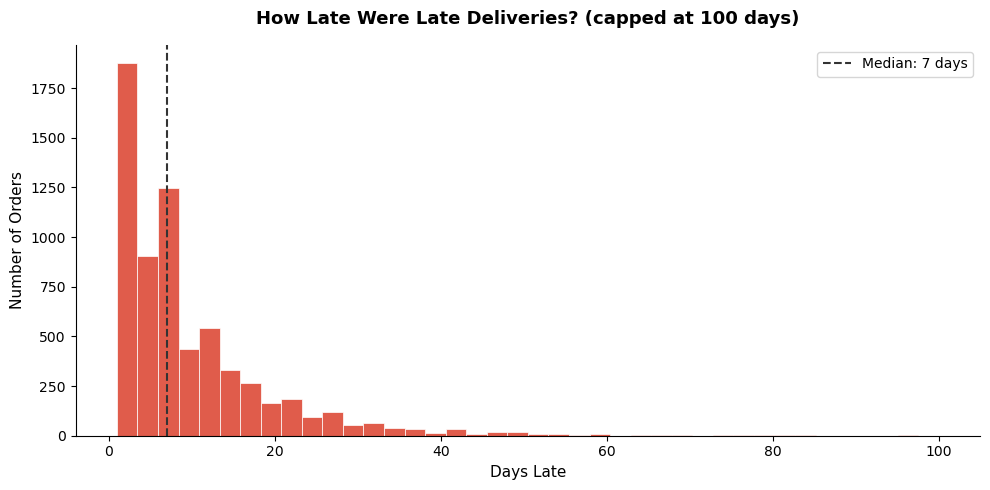

Total late orders: 6,523
Median days late: 7
Orders 30+ days late: 323


In [21]:
late_orders = df[df['is_late'] == True]['delivery_delay_days'].dropna()
late_orders = late_orders[late_orders <= 100]

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(late_orders, bins=40, color='#e05c4b', edgecolor='white', linewidth=0.5)

median_val = late_orders.median()
ax.axvline(median_val, color='#333', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.0f} days')

ax.set_xlabel('Days Late', fontsize=11)
ax.set_ylabel('Number of Orders', fontsize=11)
ax.set_title('How Late Were Late Deliveries? (capped at 100 days)', fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f'Total late orders: {len(late_orders):,}')
print(f'Median days late: {median_val:.0f}')
print(f'Orders 30+ days late: {(late_orders >= 30).sum():,}')